## Testing on HRI_Test_09 for cavity NN
##### wav2ecg uses loaders["train"] for trainign and loaders["valid"] for validation
##### loaders["test"] is kept by the system for inference.py
##### inference.py has no loss calculation or backpropagation algorithm
##### in cavity.py, it is shown that 09_ files are kept for "test" split

#### Procedure: 
- Load [cavity_data]conv-tasnet.pt in inference.py (aka parveen_conv-tasnet)
- Generate the processed dataset using the cavity.py 
- Save inference results as 2025_cavity_data_on_cavity_data_conv-tasnet_[cavity_data]conv-tasnet_pred.npy
- Load these files here and run the auxiliary methods to perform comparisons

#### Latest NN trained: 2025-01-22_10h22min.pt
- Training happened with files _06, _07, _08 in cavity_data folder (_09) was not in folder at the time
- Inference happened with _09 file 
- Training files and inference files were backed up in folder other_cavity_data
- Result of inference.py: 2025-01-22_10h22min_cavity_data_on_cavity_data_conv-tasnet_pred.npy and _true.npy

In [46]:
import os
from metrics import *
import utils as u 

dir_root = os.path.join("C:\\","Users",u.pc_name,"OneDrive - TMNA",
                        "ML1","wav2ecg_cavity_orig","results")

sr = 2000
#v2 file stores the 4sec windows in the right chronological order
#for testing data no overlap was used between the samples
#this can be conformed in method cavity.py/segment
data_name = "v2_2025-01-22_10h22min_cavity_data_on_cavity_data_conv-tasnet"
nn_name_full = "2025-01-22_10h22min.pt"

y_true, y_pred = evaluate_rec_v2(dir_root, data_name)

v2_2025-01-22_10h22min_cavity_data_on_cavity_data_conv-tasnet tested on v2_2025-01-22_10h22min_cavity_data_on_cavity_data_conv-tasnet:
MSE = 0.0005 ± 0.0012


In [47]:
y2_true, y2_pred = np.expand_dims(y_true, 0), np.expand_dims(y_pred, 0)
y2_true = y2_true.reshape(1, -1)
y2_pred = y2_pred.reshape(1, -1)


In [48]:
pos_true, pos_pred = r_peak_accuracy(y2_true, y2_pred, sr, error=0.005, return_pos=True)
rr_intervals(pos_true, pos_pred, sr)
heart_rate(pos_true, pos_pred, sr)

Correct: 909, Total: 910
Accuracy: 0.999
Mean RR duration = 1081.4928 msec
Predicted duration = 1080.3038 msec
Difference = 1.1890 msec
Missed peaks: 1
Mean HR = 56.5477 BPM
Predicted HR = 56.7354 BPM
Difference = 0.1877 BPM


In [49]:
data_name

'v2_2025-01-22_10h22min_cavity_data_on_cavity_data_conv-tasnet'

In [50]:
def save_plots(plt, start_time, dir_root):
    dir_save = os.path.join(dir_root, "plots", data_name)
    if not os.path.isdir(dir_save):
        os.makedirs(dir_save, exist_ok=True)
    plt.savefig(os.path.join(dir_save,str(start_time)+'.svg'), format='svg')
    plt.savefig(os.path.join(dir_save,str(start_time)+'.png'), format='png')
    
def save_csv(dir_root, start_time, time_axis, array_real, array_pred):
    import csv 

    dir_save = os.path.join(dir_root, "plots", data_name)
    if not os.path.isdir(dir_save):
        os.makedirs(dir_save, exist_ok=True)

    # Specify the filename
    dir_csv = os.path.join(dir_save,str(start_time)+'.csv')
    headers = ["Time[sec]", "ECG", "Prediction"]
    combined_data = np.vstack((headers, np.vstack((time_axis, array_real, array_pred)).T))#np.vstack((time_axis, array_real, array_pred)).T 

    # Open the file in write mode
    with open(dir_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(combined_data)


-0.07785691590992609
-0.035478680025826506


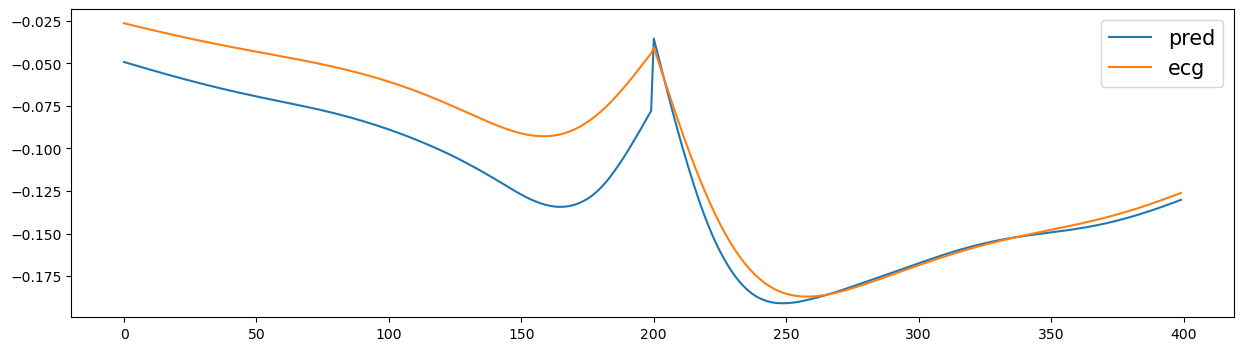

In [ ]:

#visualizing the spikes likely caused by the bandpass filter memory issues
start = 0
array_1_pred = y_pred[0,7800:8000]
array_1_true = y_true[0,7800:8000]

array_2_pred = y_pred[1,0:200]
array_2_true = y_true[1,0:200]

test_pred = np.concatenate((array_1_pred, array_2_pred))
test_true = np.concatenate((array_1_true, array_2_true))
plt.figure(figsize=(15,4))
plt.plot(test_pred, label = 'pred')
plt.plot(test_true, label = 'ecg')
plt.legend(fontsize=15)

print(y_pred[start,-1])
print(y_pred[start+1,0])

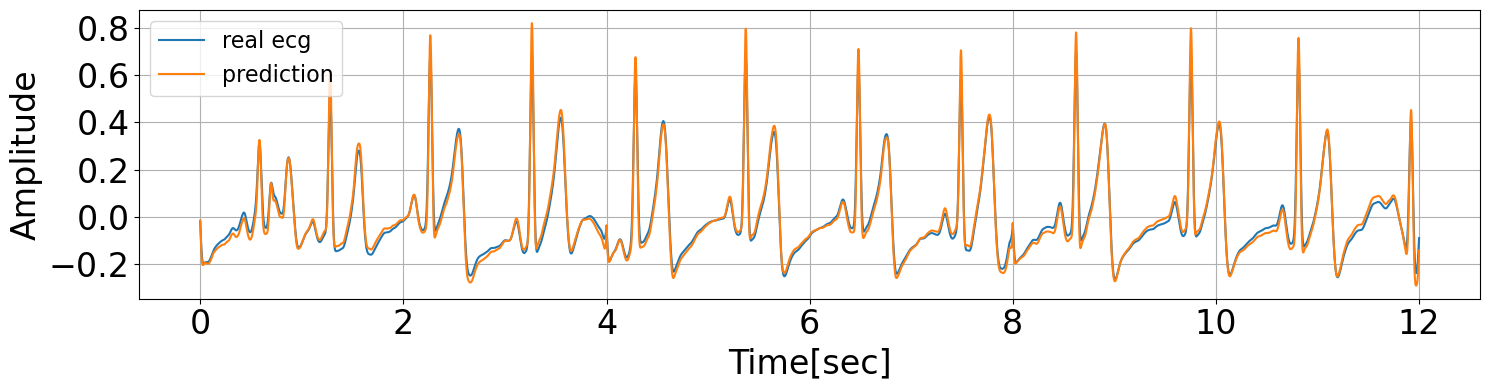

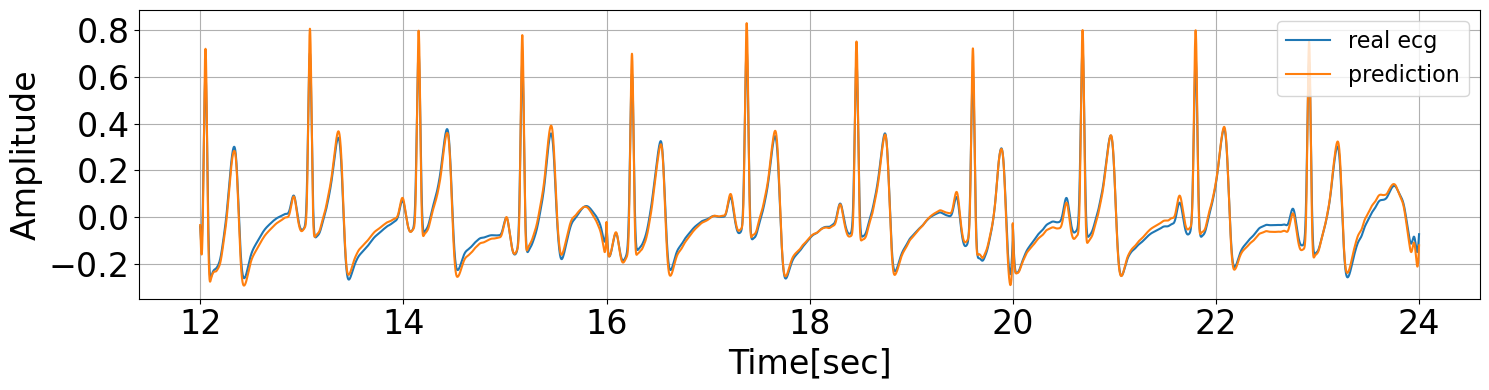

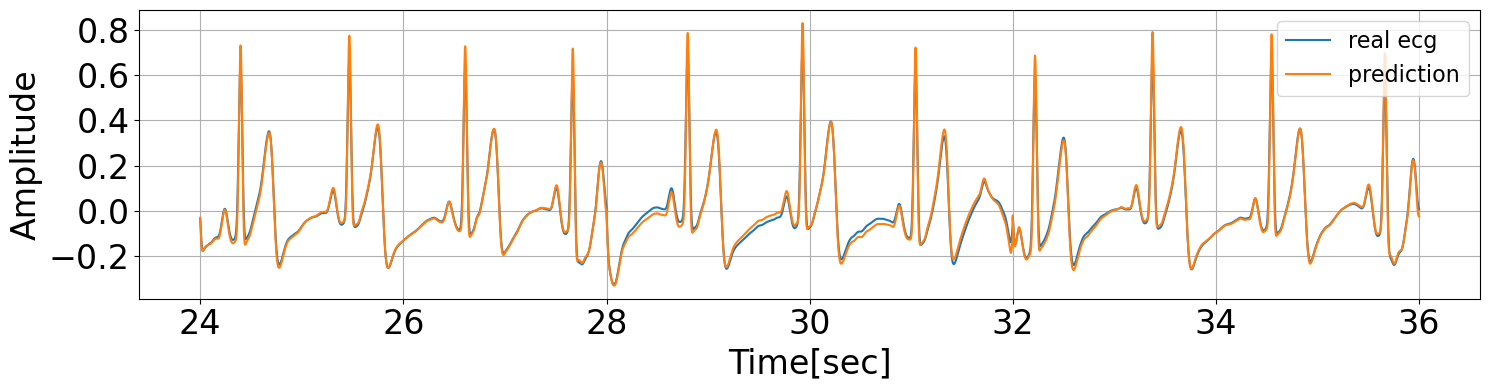

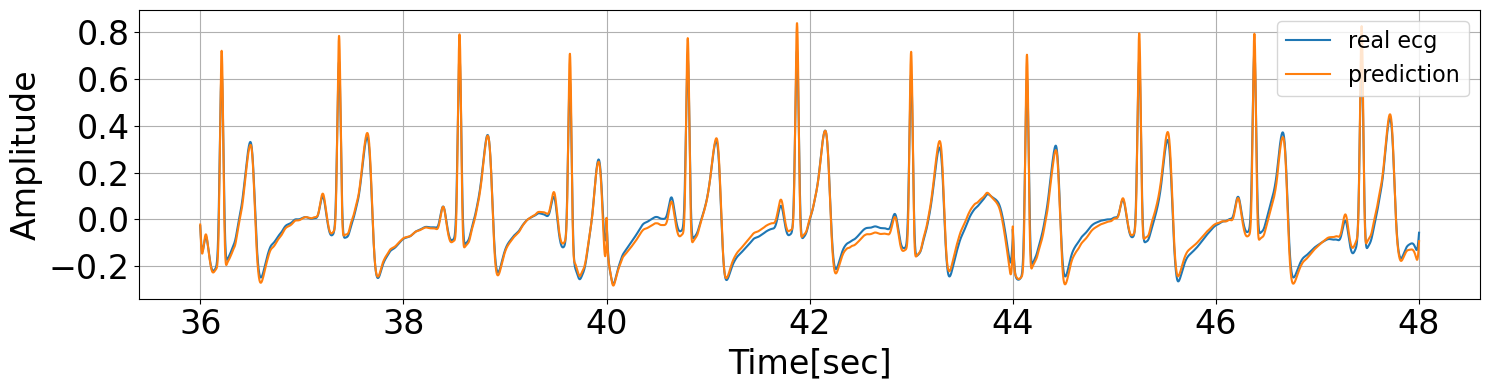

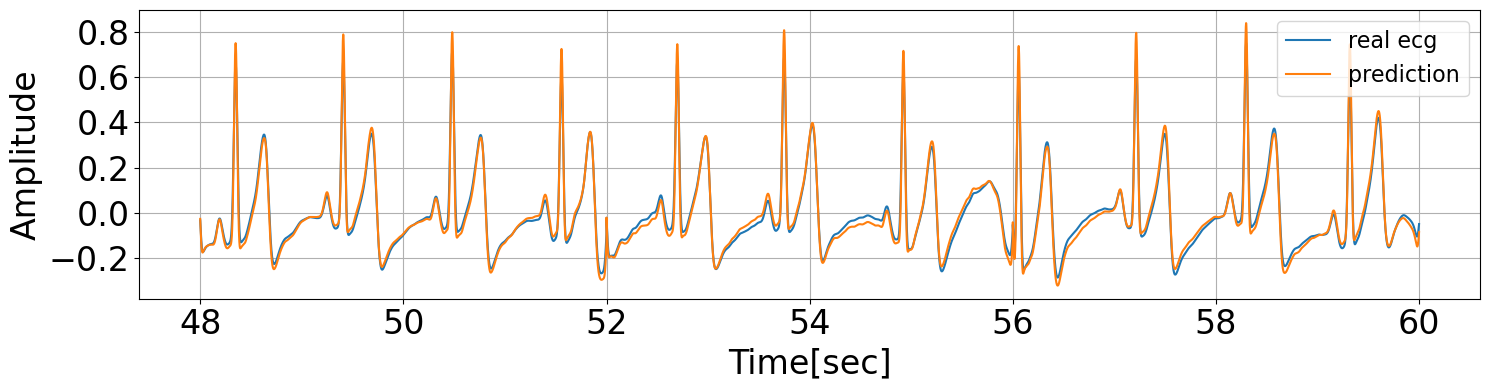

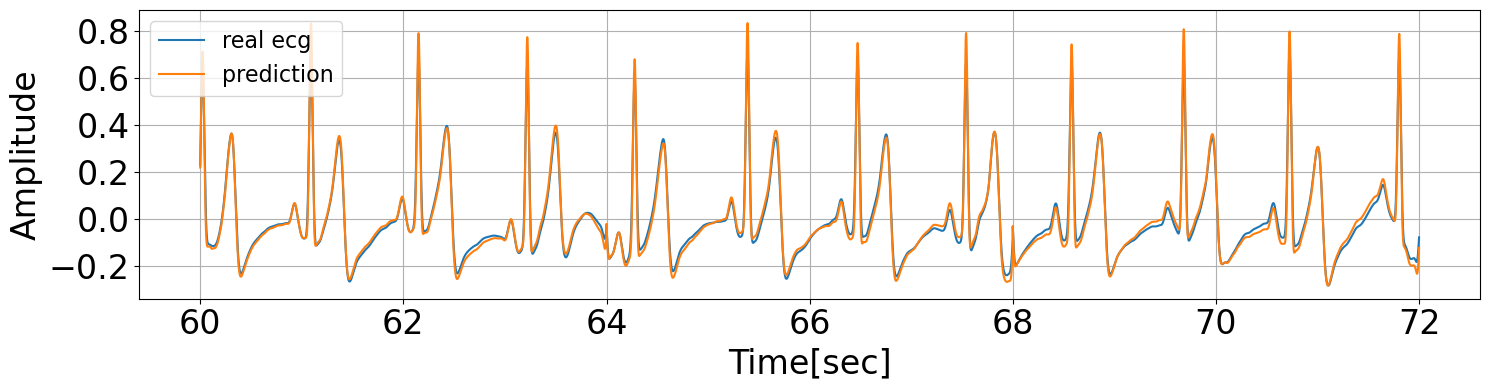

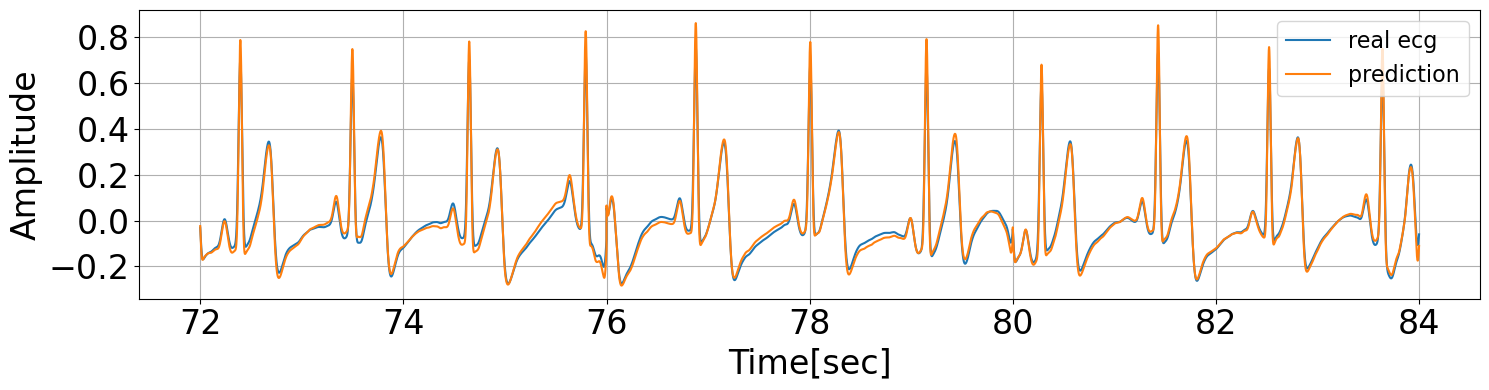

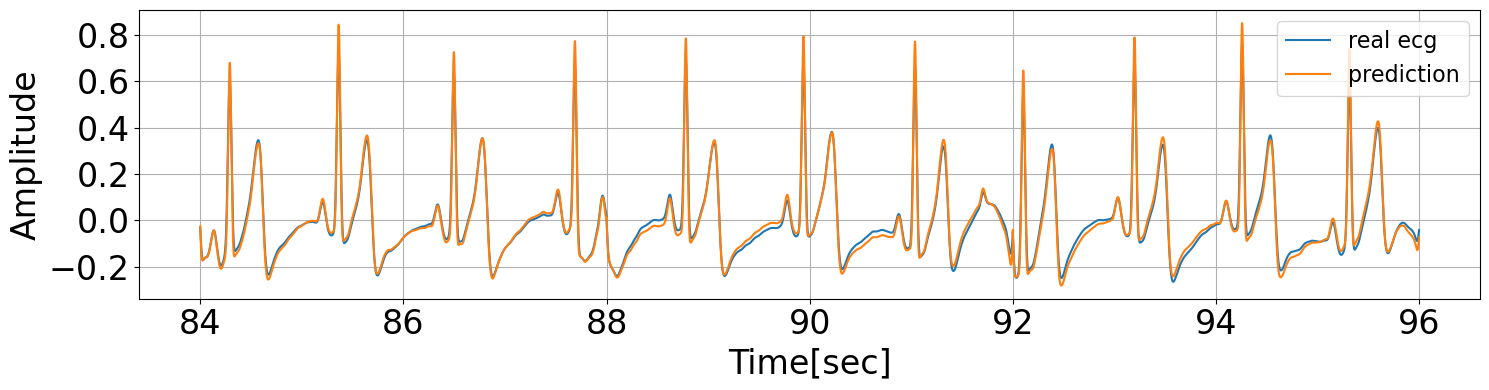

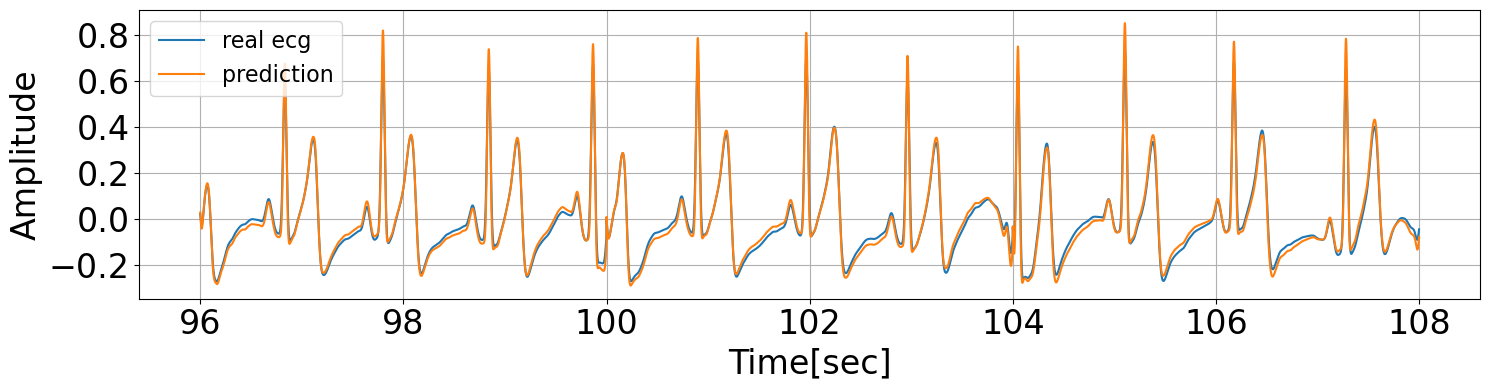

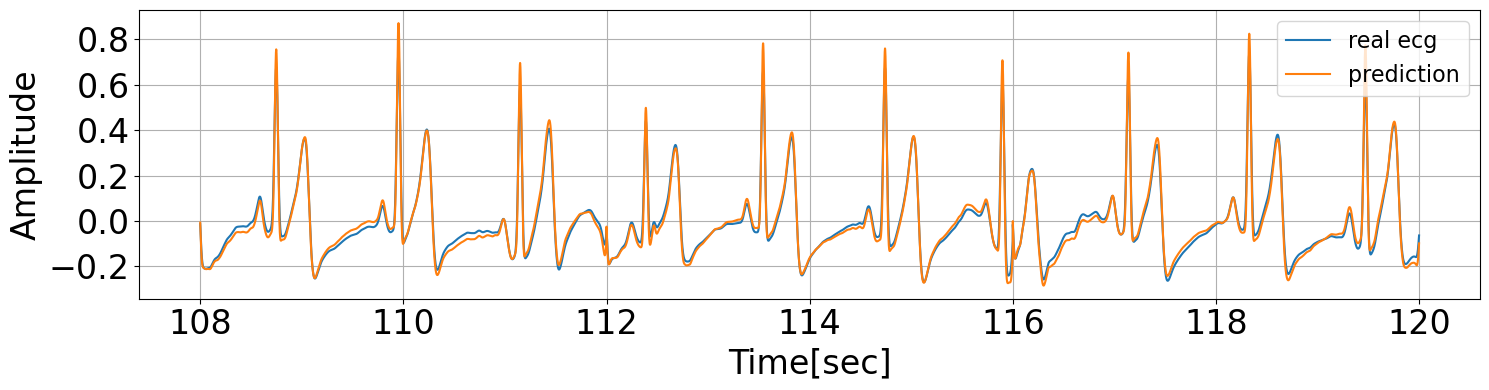

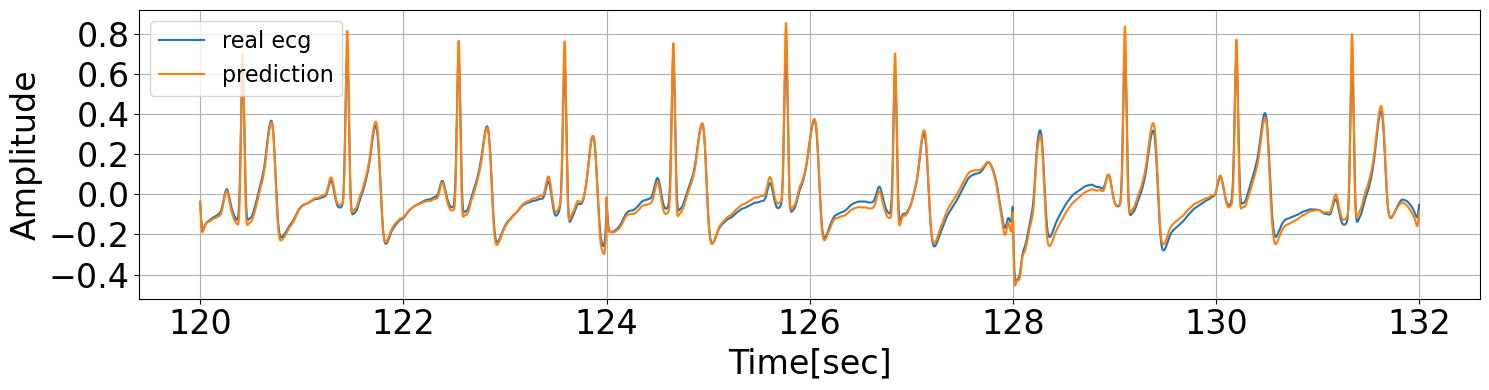

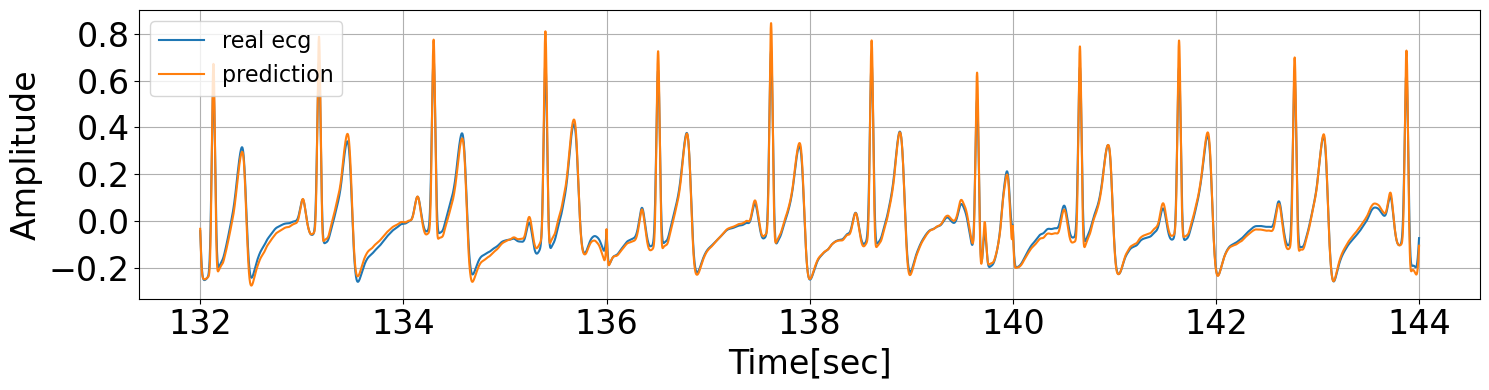

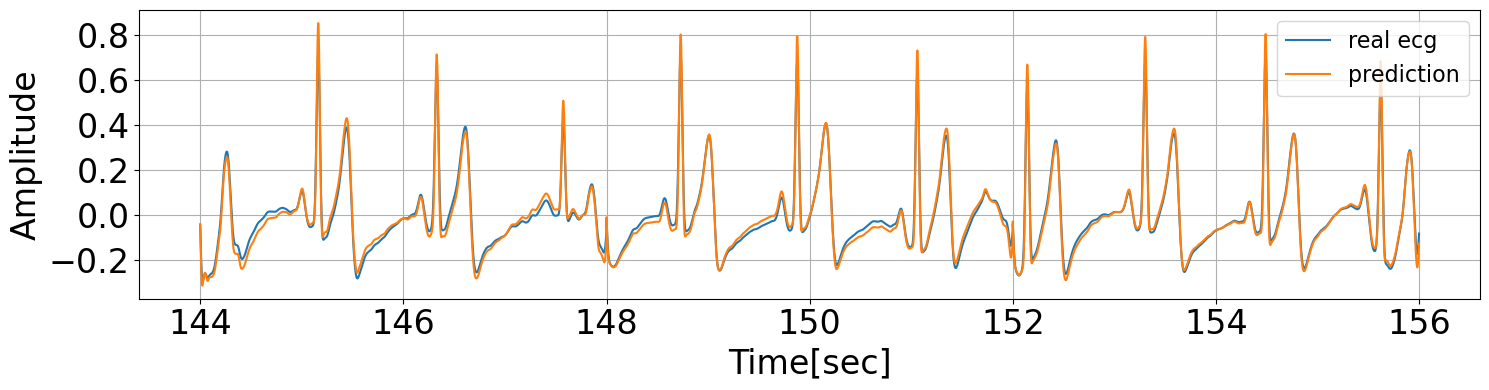

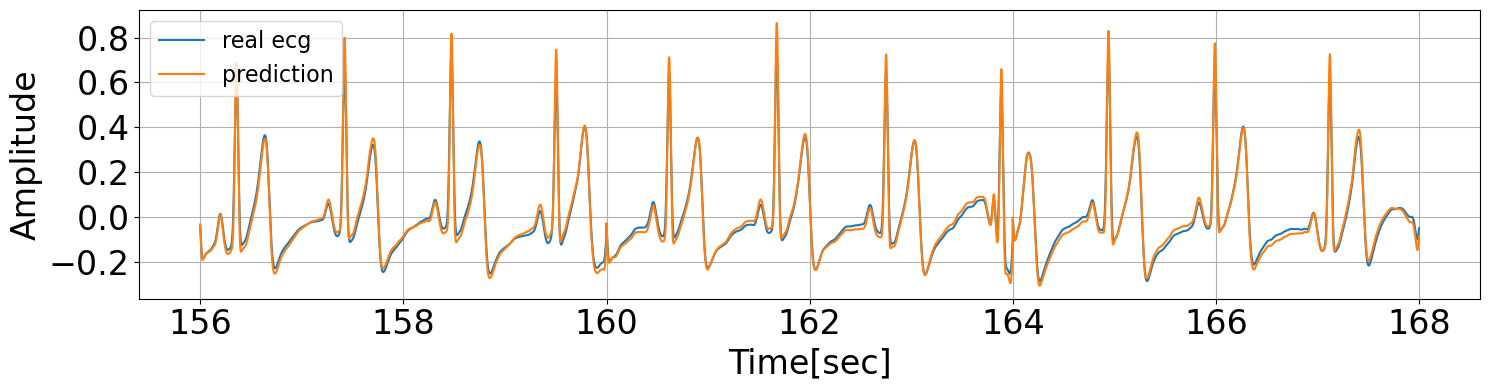

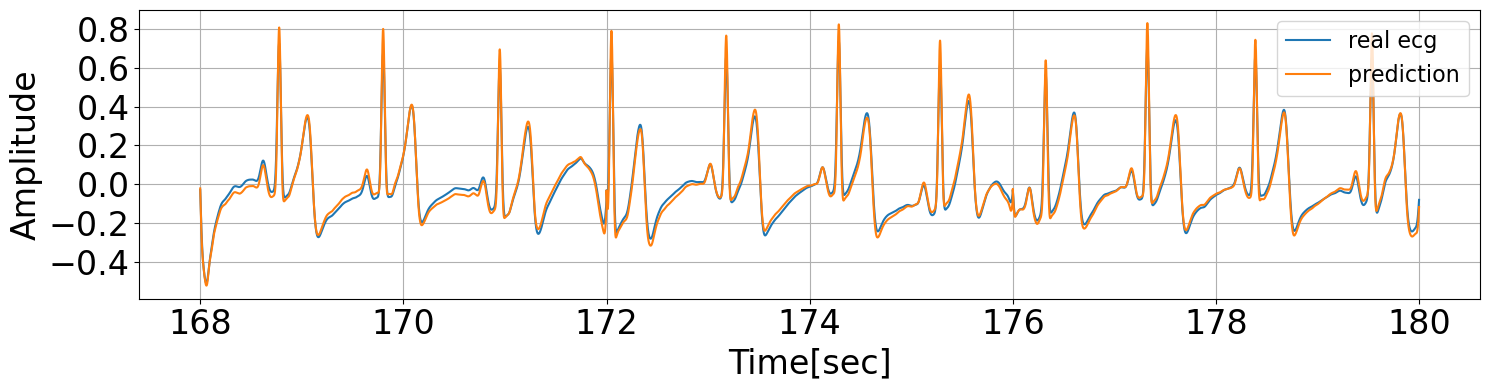

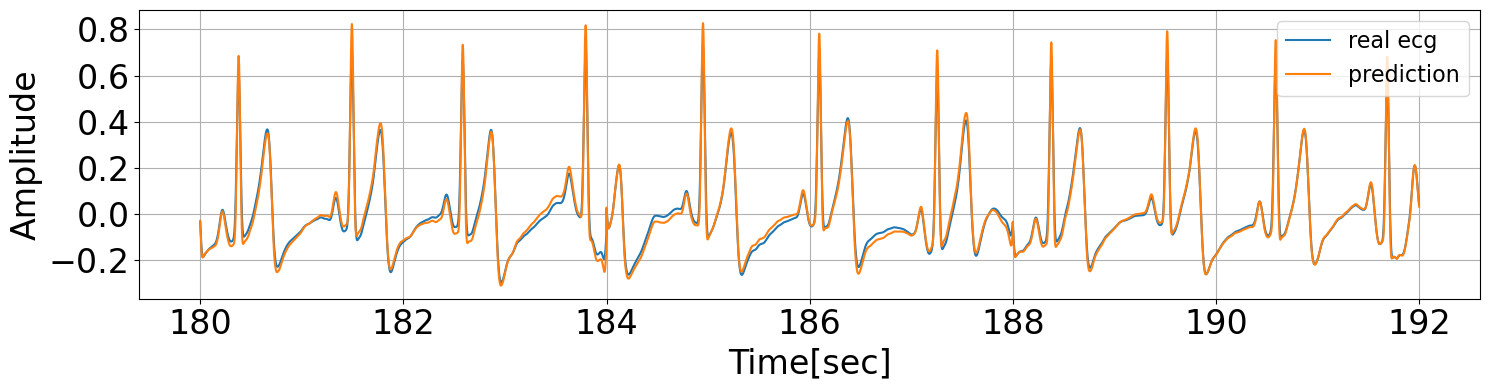

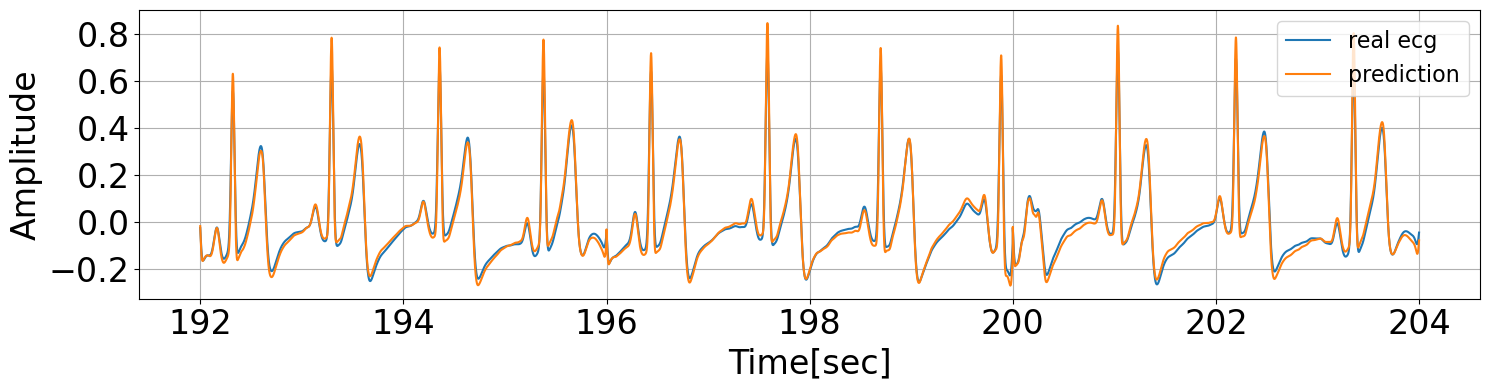

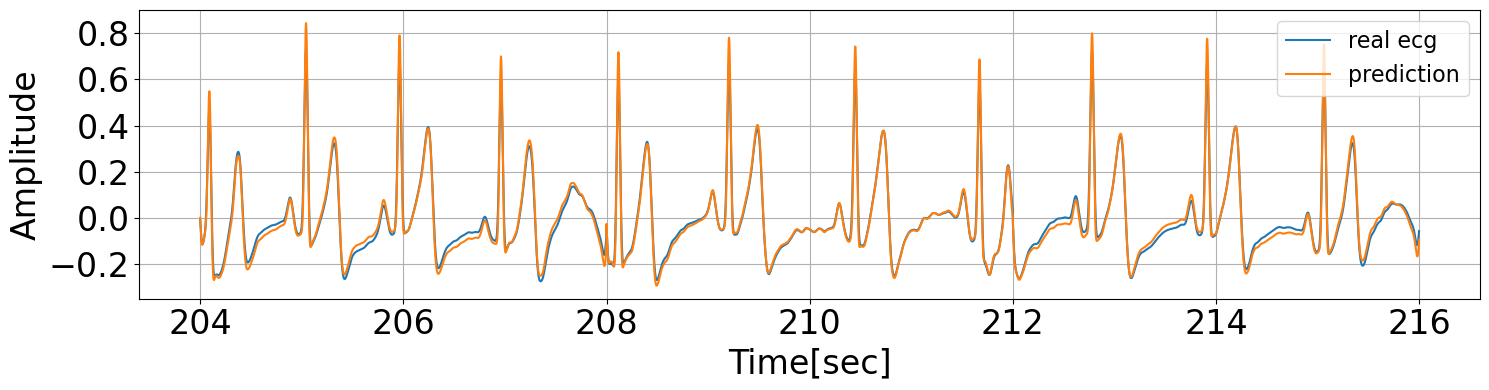

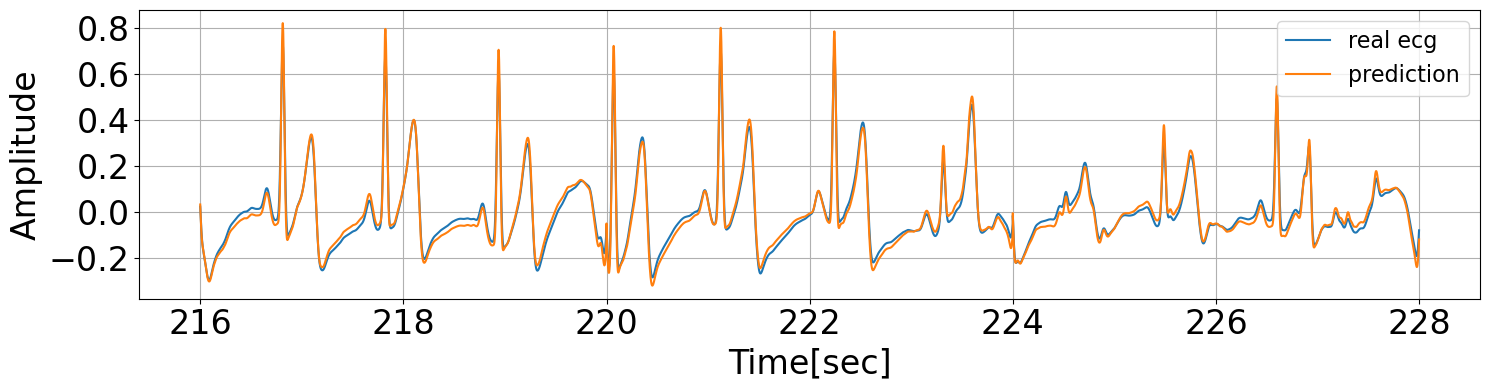

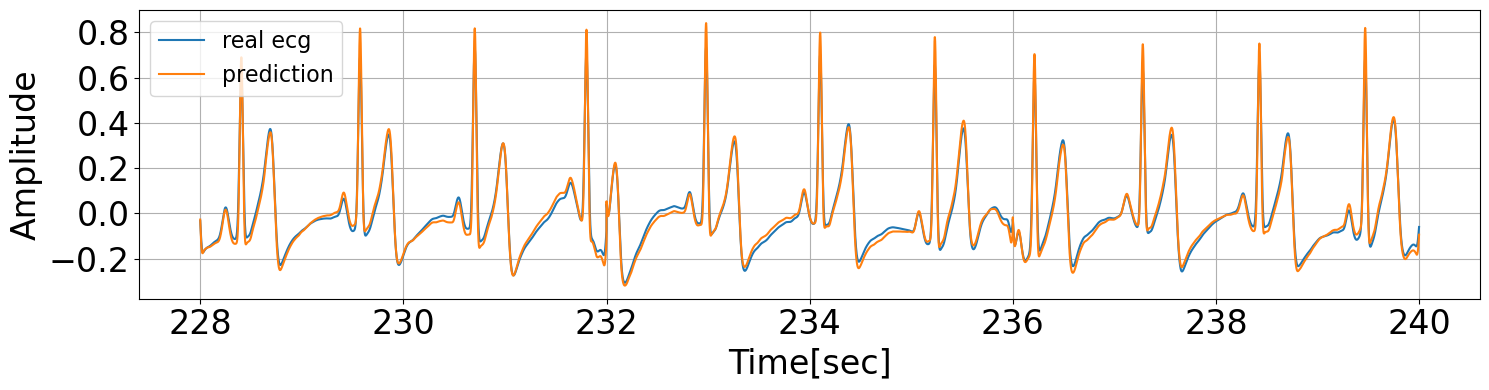

In [52]:
sample_rate = 2000
import matplotlib.pyplot as plt 


def plot_continuous_data(array_real, array_pred, duration, start_time):
    font = 24
    end_time = start_time + duration
    time_axis = np.arange(start_time, end_time, 1/sample_rate)

    plt.figure(figsize=(15,4))

    #plotting the normalized data 
    
    # plt.plot(time_axis, array_real[int(start_time*sample_rate) : int(end_time*sample_rate)], label = 'real ecg')
    # plt.plot(time_axis, array_pred[int(start_time*sample_rate) : int(end_time*sample_rate)], label = 'prediction')
    plt.plot(time_axis, array_real, label = 'real ecg')
    plt.plot(time_axis, array_pred, label = 'prediction')
    plt.xlabel('Time[sec]', fontsize=font)
    plt.xticks(fontsize=font)
    plt.ylabel('Amplitude', fontsize=font)
    plt.yticks(fontsize=font)
    str_filename = "Cavity data: HRI_Test_09"
    #plt.figtext(0.5, -0.05,f'Filename: {str_filename}, NN model: {nn_name_full}', ha='center', fontsize=10, color='gray')
    #plt.legend()
    plt.legend(fontsize=font-8)
    plt.grid(True)
    plt.tight_layout()
    save_plots(plt, start_time, dir_root)
    save_csv(dir_root, start_time, time_axis, array_real, array_pred)

     
for start_time in np.arange(0, 234, 12):
    array_real =  np.concatenate((y_true[start_time,:],
                        y_true[start_time+1,:],
                        y_true[start_time+2,:]))
    array_pred =  np.concatenate((y_pred[start_time,:],
                        y_pred[start_time+1,:],
                        y_pred[start_time+2,:]))
    plot_continuous_data(array_real, array_pred, duration=12, start_time=start_time)
